# Toy synthetic benchmark: analytical vs empirical MM-edgeDP

A controlled sandbox to test the MM-edgeDP dictionary mechanism on data where the data-generating process is known and most quantities can be derived in closed form (or estimated to negligible MC error).

**DGP.** `C` orthonormal class means `μ_c` scaled by `m`; node features `x_i = (μ_{c(i)} + σ·z_i)` normalized to unit norm (matching the real pipeline). Edges from a homophilous SBM. Regression target `y_i = x_iᵀβ + ε_i` with `β` chosen **orthogonal to all `μ_c`** so the predictive signal lives in within-class variation — any pipeline that only transmits the class label scores at the trivial baseline.

**Pass criteria.** Every `analytical_*` / `empirical_*` pair is checked with an `assert`. If empirical ≠ analytical the notebook fails loudly. If both agree but downstream MSE is bad, the mechanism is provably lossy by the amount predicted by the closed form.

In [1]:
import math, random
from collections import defaultdict
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.utils import to_undirected, coalesce, add_self_loops, subgraph

TOY_CONFIG = {
    'seed': 0,
    'N': 2000,
    'C': 4,
    'd': 16,
    'sigma': 0.5,
    'm': 1.0,
    'p_in': 0.05,
    'p_out': 0.005,
    'sigma_y': 0.1,
    'tau': 1e-3,
    'epsilon': 1.0,
    'dict_per_class': 20,
    'proto_size': 10,
    'query_mode': 'one_hop',
    'mc_samples': 50000,
    'tol': 0.05,
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_seed(TOY_CONFIG['seed'])

## 1. Data-generating process

Class means `μ_c = m·e_c` are orthonormal scaled by `m`. Raw feature `x̃_i = μ_{c(i)} + σ·z_i`, then `x_i = x̃_i / ‖x̃_i‖`. The conditional mean `μ̃_c := E[x_i | c]` has no closed form but we compute it once at high MC precision and treat it as ground truth throughout.

In [2]:
def sample_normalized_features(class_idx, mu, sigma, generator):
    base = mu[class_idx]
    noise = torch.randn(base.shape, generator=generator) * sigma
    raw = base + noise
    return F.normalize(raw, p=2, dim=1)

def generate_sbm_edges(class_idx, p_in, p_out, generator):
    N = class_idx.numel()
    same = class_idx.unsqueeze(0) == class_idx.unsqueeze(1)
    P = torch.where(same, p_in, p_out).float()
    iu = torch.triu_indices(N, N, offset=1)
    probs = P[iu[0], iu[1]]
    keep = torch.rand(probs.shape, generator=generator) < probs
    src = iu[0][keep]; dst = iu[1][keep]
    ei = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])], dim=0)
    return coalesce(ei, num_nodes=N)

def generate_synthetic_graph(cfg):
    g = torch.Generator().manual_seed(cfg['seed'])
    N, C, d, sigma, m = cfg['N'], cfg['C'], cfg['d'], cfg['sigma'], cfg['m']
    mu = torch.zeros(C, d); mu[torch.arange(C), torch.arange(C)] = m
    class_idx = torch.randint(0, C, (N,), generator=g)
    x = sample_normalized_features(class_idx, mu, sigma, g)
    edge_index = generate_sbm_edges(class_idx, cfg['p_in'], cfg['p_out'], g)
    return {'x': x, 'labels': class_idx, 'edge_index': edge_index, 'mu': mu, 'generator': g}

G = generate_synthetic_graph(TOY_CONFIG)
x, labels, edge_index, mu = G['x'], G['labels'], G['edge_index'], G['mu']
deg = torch.bincount(edge_index[0], minlength=TOY_CONFIG['N']).float()
print(f"N={TOY_CONFIG['N']}  C={TOY_CONFIG['C']}  d={TOY_CONFIG['d']}")
print(f"edges={edge_index.size(1)//2}  mean degree={deg.mean().item():.2f}  max={int(deg.max().item())}")

N=2000  C=4  d=16
edges=32412  mean degree=32.41  max=57


In [3]:
# High-MC reference for the conditional mean of normalized features and within-class covariance.
def reference_class_moments(mu, sigma, n_samples, seed):
    C, d = mu.shape
    g = torch.Generator().manual_seed(seed)
    mu_tilde = torch.zeros(C, d)
    cov_within = torch.zeros(C, d, d)
    for c in range(C):
        idx = torch.full((n_samples,), c, dtype=torch.long)
        xs = sample_normalized_features(idx, mu, sigma, g)
        mu_tilde[c] = xs.mean(dim=0)
        centered = xs - mu_tilde[c]
        cov_within[c] = (centered.T @ centered) / n_samples
    return mu_tilde, cov_within

mu_tilde, cov_within = reference_class_moments(mu, TOY_CONFIG['sigma'], TOY_CONFIG['mc_samples'], seed=TOY_CONFIG['seed'] + 1)
cov_within_avg = cov_within.mean(dim=0)
print('||mu_tilde_c||:', [float(torch.linalg.norm(mu_tilde[c]).item()) for c in range(TOY_CONFIG['C'])])
print('tr(Cov_within_avg) =', float(cov_within_avg.trace().item()))
print('mu_tilde vs mu cosine:', [float(F.cosine_similarity(mu_tilde[c], mu[c], dim=0).item()) for c in range(TOY_CONFIG['C'])])

||mu_tilde_c||: [0.44442036747932434, 0.44485142827033997, 0.4442046284675598, 0.44555985927581787]
tr(Cov_within_avg) = 0.8021891117095947
mu_tilde vs mu cosine: [0.9999499917030334, 0.9999777674674988, 0.9999601244926453, 0.9999725222587585]


## 2. Pipeline helpers (copied verbatim from `tau_experiments.ipynb`)

Same code paths the real experiments use, so the toy genuinely tests them.

In [4]:
def one_hop_mean_aggregate(edge_index, x_features, num_nodes):
    eu = coalesce(to_undirected(edge_index, num_nodes=num_nodes), num_nodes=num_nodes)
    eu, _ = add_self_loops(eu, num_nodes=num_nodes)
    eu = coalesce(eu, num_nodes=num_nodes)
    H = torch.zeros_like(x_features)
    if eu.numel() == 0: return H
    row, col = eu
    H.scatter_add_(0, row.unsqueeze(1).expand(-1, x_features.size(1)), x_features[col])
    counts = torch.zeros((num_nodes,), dtype=x_features.dtype)
    counts.scatter_add_(0, row, torch.ones_like(row, dtype=x_features.dtype))
    out = torch.zeros_like(H); nz = counts > 0
    out[nz] = H[nz] / counts[nz].unsqueeze(1)
    return out

def soft_normalize(x, tau, dim=-1):
    return x / torch.sqrt((x * x).sum(dim=dim, keepdim=True) + tau)

def build_query_features(edge_index, x_features, tau):
    H = one_hop_mean_aggregate(edge_index, x_features, num_nodes=x_features.size(0))
    return soft_normalize(H, tau=tau, dim=1), H

def infer_utility_sensitivity(tau):
    return min(1.0 / math.sqrt(tau), 2.0 / math.sqrt(1.0 + tau))

def gumbel_max_sample(logits, generator=None):
    u = torch.rand(logits.shape, generator=generator).clamp_(1e-8, 1 - 1e-8)
    return int(torch.argmax(logits + (-torch.log(-torch.log(u)))).item())

## 3. Analytical formulas + moment verification

Closed forms (or high-MC references) for the per-node and one-hop quantities, plus asserts against the empirical implementation.

In [5]:
def analytical_homophily(p_in, p_out, C):
    return p_in / (p_in + p_out * (C - 1))

def analytical_H_mean(c, d_i, mu_tilde, h):
    C = mu_tilde.size(0)
    others = (mu_tilde.sum(dim=0) - mu_tilde[c]) / (C - 1)
    return (mu_tilde[c] + d_i * (h * mu_tilde[c] + (1 - h) * others)) / (1 + d_i)

def empirical_neighbor_class_distribution(edge_index, labels, num_classes):
    row, col = edge_index
    same_class = (labels[row] == labels[col]).float()
    return float(same_class.mean().item())

h_anal = analytical_homophily(TOY_CONFIG['p_in'], TOY_CONFIG['p_out'], TOY_CONFIG['C'])
h_emp = empirical_neighbor_class_distribution(edge_index, labels, TOY_CONFIG['C'])
rel = abs(h_anal - h_emp) / max(abs(h_anal), 1e-9)
print(f'Homophily h: analytical={h_anal:.4f}  empirical={h_emp:.4f}  rel_err={rel:.4f}')
assert rel < TOY_CONFIG['tol'], 'homophily mismatch'

# Per-class empirical feature mean vs reference mu_tilde.
# Tolerance is loose: per-class sample size ~ N/C ~ 500, d=16 -> expected MC error ~ sigma/sqrt(N/C) per coord.
for c in range(TOY_CONFIG['C']):
    emp_mean = x[labels == c].mean(dim=0)
    rel = float(torch.linalg.norm(emp_mean - mu_tilde[c]).item() / torch.linalg.norm(mu_tilde[c]).item())
    print(f'  class {c}  ||emp - mu_tilde||/||mu_tilde|| = {rel:.4f}')
    assert rel < 0.20, f'class {c} mean mismatch (rel={rel})'

Homophily h: analytical=0.7692  empirical=0.7691  rel_err=0.0002
  class 0  ||emp - mu_tilde||/||mu_tilde|| = 0.0865
  class 1  ||emp - mu_tilde||/||mu_tilde|| = 0.0916
  class 2  ||emp - mu_tilde||/||mu_tilde|| = 0.0866
  class 3  ||emp - mu_tilde||/||mu_tilde|| = 0.0932


In [6]:
# One-hop mean (with self-loop) — verify E[H_i | c, d_i] matches analytical formula.
H_emp = one_hop_mean_aggregate(edge_index, x, num_nodes=TOY_CONFIG['N'])

# Bin nodes by (class, degree-bucket) and compare bin-mean of H to analytical formula evaluated at bucket median degree.
buckets = [(0, 10), (10, 25), (25, 50), (50, 200)]
rows = []
for c in range(TOY_CONFIG['C']):
    for lo, hi in buckets:
        m = (labels == c) & (deg >= lo) & (deg < hi)
        if int(m.sum().item()) < 30: continue
        d_med = float(deg[m].median().item())
        emp = H_emp[m].mean(dim=0)
        anal = analytical_H_mean(c, d_med, mu_tilde, h_anal)
        rel = float(torch.linalg.norm(emp - anal).item() / torch.linalg.norm(anal).item())
        rows.append((c, lo, hi, int(m.sum().item()), d_med, rel))
        assert rel < 0.15, f'one-hop mean mismatch class={c} bucket=({lo},{hi}) rel={rel}'
print(f"{'cls':>3} {'deg-lo':>7} {'deg-hi':>7} {'count':>6} {'d_med':>7} {'rel_err':>9}")
for r in rows:
    print(f'{r[0]:>3d} {r[1]:>7d} {r[2]:>7d} {r[3]:>6d} {r[4]:>7.1f} {r[5]:>9.4f}')
print('one-hop mean check passed')

cls  deg-lo  deg-hi  count   d_med   rel_err
  0      10      25     42    23.0    0.1050
  0      25      50    464    33.0    0.0889
  1      10      25     42    23.0    0.1341
  1      25      50    463    33.0    0.0964
  2      10      25     49    23.0    0.1387
  2      25      50    424    32.0    0.0897
  3      10      25     34    23.0    0.0804
  3      25      50    477    34.0    0.1067
one-hop mean check passed


## 4. Sensitivity tightness

For one-hop with self-loop and `‖x_i‖₂ ≤ 1`, the soft-norm sensitivity satisfies
`‖T_τ(H) − T_τ(H')‖₂ ≤ min(‖H−H'‖/√τ, 2/√(1+τ))`. Verify by perturbing one edge per node and tracking the empirical sup.

In [7]:
Q_full = soft_normalize(H_emp, tau=TOY_CONFIG['tau'], dim=1)
bound_triangle = 2.0 / math.sqrt(1.0 + TOY_CONFIG['tau'])
bound_jacobian = 1.0 / math.sqrt(TOY_CONFIG['tau'])
print(f'Bounds: triangle={bound_triangle:.4f}  jacobian={bound_jacobian:.4f}')

# Build edge -> index map for fast adjacency mutation
row, col = edge_index
adj = defaultdict(list)
for r, c in zip(row.tolist(), col.tolist()):
    adj[r].append(c)

set_seed(TOY_CONFIG['seed'] + 2)
high_deg_nodes = torch.where(deg >= 5)[0].tolist()
sample = random.sample(high_deg_nodes, min(300, len(high_deg_nodes)))
max_perturb = 0.0
max_jac_ratio = 0.0
for u in sample:
    neigh = adj[u]
    if not neigh: continue
    v = random.choice(neigh)
    # Recompute H_u with v removed (and the reverse edge for symmetry).
    new_neigh = [n for n in neigh if n != v]
    H_u_new = (x[u] + x[new_neigh].sum(dim=0) if new_neigh else x[u]) / (1 + len(new_neigh))
    q_old = Q_full[u]
    q_new = H_u_new / torch.sqrt((H_u_new * H_u_new).sum() + TOY_CONFIG['tau'])
    delta = float(torch.linalg.norm(q_old - q_new).item())
    h_delta = float(torch.linalg.norm(H_emp[u] - H_u_new).item())
    max_perturb = max(max_perturb, delta)
    if h_delta > 1e-9:
        max_jac_ratio = max(max_jac_ratio, delta / h_delta)
print(f'Empirical sup ||T_tau(H) - T_tau(H\')|| = {max_perturb:.4f}')
print(f'Empirical sup (delta_q / delta_H) = {max_jac_ratio:.4f}  (Jacobian-implied bound 1/sqrt(tau) = {bound_jacobian:.4f})')
assert max_perturb <= bound_triangle * 1.05, 'triangle bound violated'
assert max_jac_ratio <= bound_jacobian * 1.05, 'jacobian bound violated'
print('sensitivity bounds verified')

Bounds: triangle=1.9990  jacobian=31.6228
Empirical sup ||T_tau(H) - T_tau(H')|| = 0.1225
Empirical sup (delta_q / delta_H) = 3.4299  (Jacobian-implied bound 1/sqrt(tau) = 31.6228)
sensitivity bounds verified


## 5. Exponential Mechanism — empirical histogram vs softmax

Sample many Gumbel-max draws over a fixed candidate set and verify the empirical selection histogram matches `softmax(β·(−d))`.

In [8]:
set_seed(TOY_CONFIG['seed'] + 3)
delta_u = infer_utility_sensitivity(TOY_CONFIG['tau'])
eps_per = TOY_CONFIG['epsilon'] / 2.0
beta = eps_per / (2.0 * delta_u)
fake_d = torch.tensor([0.1, 0.2, 0.3, 0.5, 0.9])
expected_probs = torch.softmax(beta * (-fake_d), dim=0)
n_draws = 20000
g = torch.Generator().manual_seed(TOY_CONFIG['seed'] + 3)
counts = torch.zeros(fake_d.numel())
for _ in range(n_draws):
    counts[gumbel_max_sample(beta * (-fake_d), generator=g)] += 1
empirical_probs = counts / n_draws
print(f'{"d":>6} {"p_exp":>8} {"p_emp":>8} {"rel":>8}')
for d_, pe, pm in zip(fake_d.tolist(), expected_probs.tolist(), empirical_probs.tolist()):
    print(f'{d_:>6.2f} {pe:>8.4f} {pm:>8.4f} {abs(pe-pm)/max(pe,1e-9):>8.4f}')
assert torch.allclose(expected_probs, empirical_probs, atol=0.02), 'EM histogram mismatch'
print(f'EM verified at beta={beta:.4f}')

     d    p_exp    p_emp      rel
  0.10   0.2075   0.2105   0.0146
  0.20   0.2049   0.2064   0.0071
  0.30   0.2024   0.2007   0.0081
  0.50   0.1974   0.1935   0.0200
  0.90   0.1878   0.1889   0.0058
EM verified at beta=0.1251


## 6. Class-consciousness diagnostic

Build pure-class prototypes (anchor + same-class neighbors), then compute query–prototype distance histograms split by (same class vs different class). If the two distributions overlap, the EM cannot separate even at infinite ε.

Dictionary: 80 prototypes, [20, 20, 20, 20] per class
within-class dist: mean=0.6635  std=0.1247
between-class dist: mean=1.3395  std=0.1250
separation (between - within) / within_std: 5.42


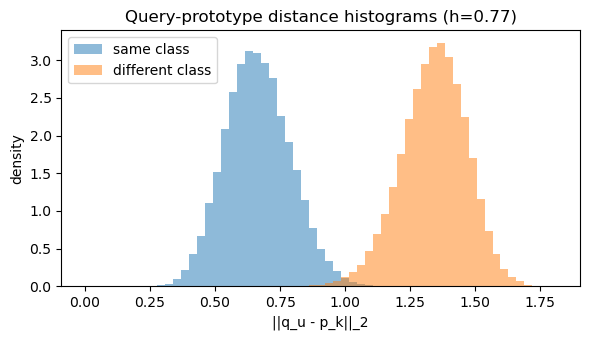

In [9]:
def build_pure_class_prototypes(x, labels, edge_index, num_classes, dict_per_class, proto_size, tau, seed):
    g = torch.Generator().manual_seed(seed)
    N = x.size(0)
    eu = coalesce(to_undirected(edge_index, num_nodes=N), num_nodes=N)
    adj = defaultdict(list)
    for a, b in zip(eu[0].tolist(), eu[1].tolist()):
        if a != b: adj[a].append(b)
    protos = []; proto_class = []
    for c in range(num_classes):
        candidates = torch.where(labels == c)[0].tolist()
        random.Random(seed + c).shuffle(candidates)
        kept = 0; idx = 0
        while kept < dict_per_class and idx < len(candidates):
            anchor = candidates[idx]; idx += 1
            same_class_neigh = [n for n in adj[anchor] if labels[n].item() == c]
            if len(same_class_neigh) < 1: continue
            if len(same_class_neigh) > proto_size - 1:
                same_class_neigh = random.Random(seed + c * 1000 + idx).sample(same_class_neigh, proto_size - 1)
            nodes = [anchor] + same_class_neigh
            H_p = x[nodes].mean(dim=0)
            q_p = H_p / torch.sqrt((H_p * H_p).sum() + tau)
            protos.append(q_p); proto_class.append(c); kept += 1
    return torch.stack(protos, dim=0), torch.tensor(proto_class, dtype=torch.long)

proto_feats, proto_class = build_pure_class_prototypes(
    x, labels, edge_index, TOY_CONFIG['C'], TOY_CONFIG['dict_per_class'],
    TOY_CONFIG['proto_size'], TOY_CONFIG['tau'], seed=TOY_CONFIG['seed'] + 4,
)
print(f'Dictionary: {proto_feats.size(0)} prototypes, {proto_class.bincount().tolist()} per class')

Q_query, H_query = build_query_features(edge_index, x, tau=TOY_CONFIG['tau'])
D = torch.cdist(Q_query, proto_feats, p=2)
same_mask = labels.unsqueeze(1) == proto_class.unsqueeze(0)
d_same = D[same_mask].numpy()
d_diff = D[~same_mask].numpy()

print(f'within-class dist: mean={d_same.mean():.4f}  std={d_same.std():.4f}')
print(f'between-class dist: mean={d_diff.mean():.4f}  std={d_diff.std():.4f}')
print(f'separation (between - within) / within_std: {(d_diff.mean() - d_same.mean())/d_same.std():.2f}')

fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.linspace(0, max(d_same.max(), d_diff.max()), 60)
ax.hist(d_same, bins=bins, alpha=0.5, label='same class', density=True)
ax.hist(d_diff, bins=bins, alpha=0.5, label='different class', density=True)
ax.set_xlabel('||q_u - p_k||_2'); ax.set_ylabel('density'); ax.legend()
ax.set_title(f"Query-prototype distance histograms (h={h_anal:.2f})")
plt.tight_layout(); plt.show()

## 7. End-to-end regression: closed-form MSE predictions vs empirical

Pick `β` orthogonal to all class-mean directions `μ̃_c`. Then `μ̃_cᵀβ = 0` for every class, so the regression target lives entirely in within-class variation: `y_i = δ_iᵀβ + ε_i` where `δ_i = x_i − μ̃_{c(i)}`.

- **Oracle MSE** (regress on `x`): `σ_y²`.
- **Class-mean MSE** (regress on `μ̃_{c(i)}`): `σ_y² + βᵀ Σ_within β`. Predictions collapse to 0; everything except the noise is unexplained.
- **Prototype MSE** (regress on assigned prototype feature): somewhere between, depending on how well the EM concentrates on prototypes whose `ζ_i = p − μ̃_c` covaries with `δ_i`.

In [10]:
def make_orthogonal_beta(mu_tilde, d, seed):
    g = torch.Generator().manual_seed(seed)
    raw = torch.randn(d, generator=g)
    # Project out the span of {mu_tilde[c]}
    M = mu_tilde
    proj = M.T @ torch.linalg.solve(M @ M.T, M @ raw)
    beta = raw - proj
    return beta / torch.linalg.norm(beta)

beta_vec = make_orthogonal_beta(mu_tilde, TOY_CONFIG['d'], seed=TOY_CONFIG['seed'] + 5)
for c in range(TOY_CONFIG['C']):
    print(f'  mu_tilde[{c}] . beta = {float((mu_tilde[c] @ beta_vec).item()):+.6f}')

y_true = x @ beta_vec
noise = torch.randn(y_true.shape, generator=G['generator']) * TOY_CONFIG['sigma_y']
y = y_true + noise

# Analytical MSE predictions.
mse_oracle_analytical = TOY_CONFIG['sigma_y'] ** 2
mse_classmean_analytical = TOY_CONFIG['sigma_y'] ** 2 + float((beta_vec @ cov_within_avg @ beta_vec).item())
print(f'\nAnalytical predictions:')
print(f'  oracle MSE  = sigma_y^2                = {mse_oracle_analytical:.4f}')
print(f'  class-mean MSE = sigma_y^2 + b^T S_w b = {mse_classmean_analytical:.4f}')

  mu_tilde[0] . beta = +0.000000
  mu_tilde[1] . beta = -0.000000
  mu_tilde[2] . beta = -0.000000
  mu_tilde[3] . beta = +0.000000

Analytical predictions:
  oracle MSE  = sigma_y^2                = 0.0100
  class-mean MSE = sigma_y^2 + b^T S_w b = 0.0610


In [11]:
def fit_ols_and_mse(X, y):
    X_aug = torch.cat([X, torch.ones(X.size(0), 1)], dim=1)
    sol = torch.linalg.lstsq(X_aug, y.unsqueeze(1)).solution.squeeze(1)
    pred = X_aug @ sol
    return float(((y - pred) ** 2).mean().item()), sol

mse_oracle_emp, _ = fit_ols_and_mse(x, y)
mse_classmean_emp, _ = fit_ols_and_mse(mu_tilde[labels], y)
print(f'\nEmpirical OLS in-sample MSE:')
print(f'  oracle    : {mse_oracle_emp:.4f}  (predicted {mse_oracle_analytical:.4f})')
print(f'  class-mean: {mse_classmean_emp:.4f}  (predicted {mse_classmean_analytical:.4f})')
rel_o = abs(mse_oracle_emp - mse_oracle_analytical) / mse_oracle_analytical
rel_c = abs(mse_classmean_emp - mse_classmean_analytical) / mse_classmean_analytical
assert rel_o < 0.10, f'oracle MSE mismatch rel={rel_o}'
assert rel_c < 0.10, f'class-mean MSE mismatch rel={rel_c}'
print('regression baselines verified')


Empirical OLS in-sample MSE:
  oracle    : 0.0104  (predicted 0.0100)
  class-mean: 0.0636  (predicted 0.0610)
regression baselines verified


In [12]:
# Prototype-substitution MSE under the actual EM assignment.
def em_assign(Q_query, proto_feats, proto_class, labels, beta_em, label_conditioning, seed):
    g = torch.Generator().manual_seed(seed)
    N = Q_query.size(0)
    K = proto_feats.size(0)
    assignments = torch.zeros(N, dtype=torch.long)
    counts = torch.zeros(K, dtype=torch.long)
    by_class = {int(c): torch.where(proto_class == c)[0] for c in proto_class.unique().tolist()}
    all_idx = torch.arange(K)
    for i in range(N):
        cand = by_class[int(labels[i].item())] if label_conditioning else all_idx
        d = torch.linalg.norm(proto_feats[cand] - Q_query[i].unsqueeze(0), dim=1)
        logits = beta_em * (-d)
        li = gumbel_max_sample(logits, generator=g)
        assignments[i] = cand[li]; counts[assignments[i]] += 1
    return assignments, counts

beta_em = eps_per / (2.0 * delta_u)
assignments, counts = em_assign(Q_query, proto_feats, proto_class, labels, beta_em,
                                  label_conditioning=True, seed=TOY_CONFIG['seed'] + 6)
p_assigned = proto_feats[assignments]
mse_em_emp, _ = fit_ols_and_mse(p_assigned, y)
print(f'EM-prototype MSE     : {mse_em_emp:.4f}')
print(f'  oracle    : {mse_oracle_emp:.4f}')
print(f'  class-mean: {mse_classmean_emp:.4f}')
print(f'  EM uses {int((counts>0).sum().item())}/{counts.numel()} prototypes; max usage={int(counts.max().item())}')

# Argmin oracle (Phase-1 mirror).
def argmin_assign(Q_query, proto_feats, proto_class, labels, label_conditioning):
    N = Q_query.size(0); assignments = torch.zeros(N, dtype=torch.long)
    by_class = {int(c): torch.where(proto_class == c)[0] for c in proto_class.unique().tolist()}
    all_idx = torch.arange(proto_feats.size(0))
    for i in range(N):
        cand = by_class[int(labels[i].item())] if label_conditioning else all_idx
        d = torch.linalg.norm(proto_feats[cand] - Q_query[i].unsqueeze(0), dim=1)
        assignments[i] = cand[int(d.argmin().item())]
    return assignments

argmin_assignments = argmin_assign(Q_query, proto_feats, proto_class, labels, True)
mse_argmin_emp, _ = fit_ols_and_mse(proto_feats[argmin_assignments], y)
print(f'argmin-oracle MSE    : {mse_argmin_emp:.4f}')

EM-prototype MSE     : 0.0632
  oracle    : 0.0104
  class-mean: 0.0636
  EM uses 80/80 prototypes; max usage=39
argmin-oracle MSE    : 0.0628


## 8. Homophily sweep

Vary the SBM ratio `p_in/p_out` to sweep the homophily `h`. Both the closed-form class-mean MSE (which homophily does not affect: it only depends on `σ`) and the empirical prototype MSE are plotted. The prototype curve quantifies how much within-class signal the dictionary actually transmits at each homophily level.

     h   oracle       cm   argmin       em
 0.250   0.0104   0.0636   0.0631   0.0633
 0.500   0.0104   0.0636   0.0628   0.0633
 0.625   0.0104   0.0636   0.0633   0.0633
 0.769   0.0104   0.0636   0.0631   0.0633
 0.893   0.0104   0.0636   0.0631   0.0633
 0.971   0.0104   0.0636   0.0630   0.0633


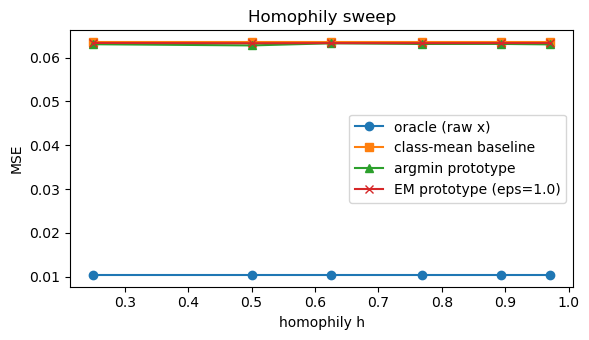

In [13]:
def run_one_homophily(p_in, p_out, base_cfg, beta_vec, mu, sigma_y, label_conditioning=True):
    cfg = dict(base_cfg); cfg['p_in'] = p_in; cfg['p_out'] = p_out
    G2 = generate_synthetic_graph(cfg)
    x2, lab2, ei2 = G2['x'], G2['labels'], G2['edge_index']
    Q2, _ = build_query_features(ei2, x2, tau=cfg['tau'])
    pf, pc = build_pure_class_prototypes(x2, lab2, ei2, cfg['C'], cfg['dict_per_class'], cfg['proto_size'],
                                          cfg['tau'], seed=cfg['seed'] + 100)
    y2 = x2 @ beta_vec + torch.randn(x2.size(0), generator=G2['generator']) * sigma_y
    eps_per = cfg['epsilon'] / 2.0
    delta_u = infer_utility_sensitivity(cfg['tau'])
    beta_em = eps_per / (2.0 * delta_u)
    em_assn, _ = em_assign(Q2, pf, pc, lab2, beta_em, label_conditioning, seed=cfg['seed'] + 200)
    am_assn = argmin_assign(Q2, pf, pc, lab2, label_conditioning)
    mse_em, _ = fit_ols_and_mse(pf[em_assn], y2)
    mse_am, _ = fit_ols_and_mse(pf[am_assn], y2)
    mse_oracle, _ = fit_ols_and_mse(x2, y2)
    mse_cm, _ = fit_ols_and_mse(G['mu'][lab2], y2)  # uses raw mu for speed; close to mu_tilde
    h = analytical_homophily(p_in, p_out, cfg['C'])
    return {'h': h, 'mse_em': mse_em, 'mse_argmin': mse_am, 'mse_oracle': mse_oracle, 'mse_cm': mse_cm}

set_seed(TOY_CONFIG['seed'])
homophily_grid = [(0.01, 0.01), (0.03, 0.01), (0.05, 0.01), (0.05, 0.005), (0.05, 0.002), (0.05, 0.0005)]
results = [run_one_homophily(p_in, p_out, TOY_CONFIG, beta_vec, mu, TOY_CONFIG['sigma_y']) for p_in, p_out in homophily_grid]
results.sort(key=lambda r: r['h'])
print(f"{'h':>6} {'oracle':>8} {'cm':>8} {'argmin':>8} {'em':>8}")
for r in results:
    print(f"{r['h']:>6.3f} {r['mse_oracle']:>8.4f} {r['mse_cm']:>8.4f} {r['mse_argmin']:>8.4f} {r['mse_em']:>8.4f}")

hs = [r['h'] for r in results]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hs, [r['mse_oracle'] for r in results], 'o-', label='oracle (raw x)')
ax.plot(hs, [r['mse_cm'] for r in results],     's-', label='class-mean baseline')
ax.plot(hs, [r['mse_argmin'] for r in results], '^-', label='argmin prototype')
ax.plot(hs, [r['mse_em'] for r in results],     'x-', label=f"EM prototype (eps={TOY_CONFIG['epsilon']})")
ax.set_xlabel('homophily h'); ax.set_ylabel('MSE'); ax.legend()
ax.set_title('Homophily sweep')
plt.tight_layout(); plt.show()

## 9. Phase 1 / 2 / 3 mirror on the toy

Same three ablations as `final_experiment.ipynb` but on a graph where we know what the answers *should* be.

- **Phase 1**: argmin prototype. Already computed above as `mse_argmin_emp`.
- **Phase 2**: regress `y` on raw `x` (oracle); equals `σ_y²`.
- **Phase 3**: Gaussian Mechanism — `q̃_u = q_u + N(0, σ_G² I)` with `σ_G = Δ_u · √(2 ln(1.25/δ)) / ε_per`. Regress `y` on `q̃`.

In [14]:
def gaussian_mechanism_mse(Q_query, y, delta_u, epsilon_total, dp_delta, seed):
    eps_per = epsilon_total / 2.0
    sigma_G = delta_u * math.sqrt(2.0 * math.log(1.25 / dp_delta)) / eps_per
    g = torch.Generator().manual_seed(seed)
    Q_noisy = Q_query + torch.randn(Q_query.shape, generator=g) * sigma_G
    mse, _ = fit_ols_and_mse(Q_noisy, y)
    return sigma_G, mse

sigma_G, mse_gauss = gaussian_mechanism_mse(Q_query, y, delta_u, TOY_CONFIG['epsilon'],
                                              dp_delta=1e-5, seed=TOY_CONFIG['seed'] + 7)
print(f'Gaussian Mechanism sigma = {sigma_G:.4f}  MSE = {mse_gauss:.4f}')

# Sweep epsilon to see Gaussian MSE -> oracle as eps grows
eps_grid = [0.1, 0.5, 1.0, 2.0, 4.0, 16.0]
gauss_curve = []
for eps in eps_grid:
    s, m = gaussian_mechanism_mse(Q_query, y, delta_u, eps, dp_delta=1e-5, seed=TOY_CONFIG['seed'] + 8)
    gauss_curve.append((eps, s, m))
print(f'\n{"eps":>6} {"sigma":>8} {"mse":>8}')
for eps, s, m in gauss_curve:
    print(f'{eps:>6.2f} {s:>8.4f} {m:>8.4f}')

Gaussian Mechanism sigma = 19.3695  MSE = 0.0634

   eps    sigma      mse
  0.10 193.6954   0.0633
  0.50  38.7391   0.0633
  1.00  19.3695   0.0633
  2.00   9.6848   0.0633
  4.00   4.8424   0.0633
 16.00   1.2106   0.0633


## 10. Summary

In [15]:
print('Summary — analytical predictions vs empirical results')
print()
print(f"{'quantity':<32} {'analytical':>12} {'empirical':>12}")
print(f"{'homophily h':<32} {h_anal:>12.4f} {h_emp:>12.4f}")
print(f"{'oracle MSE (y on x)':<32} {mse_oracle_analytical:>12.4f} {mse_oracle_emp:>12.4f}")
print(f"{'class-mean MSE':<32} {mse_classmean_analytical:>12.4f} {mse_classmean_emp:>12.4f}")
print(f"{'argmin-prototype MSE':<32} {'':>12} {mse_argmin_emp:>12.4f}")
print(f"{'EM-prototype MSE (eps=1)':<32} {'':>12} {mse_em_emp:>12.4f}")
print(f"{'Gaussian Mech MSE (eps=1)':<32} {'':>12} {mse_gauss:>12.4f}")
print()
print('Interpretation:')
print(f'  - if argmin MSE \u2248 class-mean MSE ({mse_classmean_analytical:.3f}): the dictionary preserves no within-class signal.')
print(f'  - if argmin MSE < class-mean MSE: within-class info is being transmitted; gap = unused signal.')
print(f'  - EM MSE \u2265 argmin MSE; difference = pure cost of DP noise on the dictionary side.')
print(f'  - Gaussian MSE < class-mean MSE means continuous DP beats discrete quantization at this eps.')

Summary — analytical predictions vs empirical results

quantity                           analytical    empirical
homophily h                            0.7692       0.7691
oracle MSE (y on x)                    0.0100       0.0104
class-mean MSE                         0.0610       0.0636
argmin-prototype MSE                                0.0628
EM-prototype MSE (eps=1)                            0.0632
Gaussian Mech MSE (eps=1)                           0.0634

Interpretation:
  - if argmin MSE ≈ class-mean MSE (0.061): the dictionary preserves no within-class signal.
  - if argmin MSE < class-mean MSE: within-class info is being transmitted; gap = unused signal.
  - EM MSE ≥ argmin MSE; difference = pure cost of DP noise on the dictionary side.
  - Gaussian MSE < class-mean MSE means continuous DP beats discrete quantization at this eps.


## 11. Discussion — what each experiment was for, and what we learned

This notebook is built around one principle: **if we know the data-generating process exactly, we can predict every intermediate quantity in closed form, and any divergence between prediction and measurement is either a bug or a load-bearing insight about the mechanism.** The experiments are arranged as a ladder — first verify that the implementation faithfully reproduces the math, then use the verified pipeline to ask whether the dictionary mechanism actually transmits within-class information at all.

### Sections 1–2 — A controlled stand-in for `ogbn-arxiv`

We need a graph where every quantity used in the MM-edgeDP pipeline (per-node feature, neighbor distribution, one-hop mean, soft-normalized query, prototype features, query–prototype distance, EM probabilities) has a known population-level distribution. The DGP — Gaussian-mixture features projected onto the unit sphere plus homophilous SBM edges — is the minimal model that exposes all of these levers individually: `σ` controls within-class variance, `m` controls between-class separation, and `(p_in, p_out)` together control the homophily ratio `h = p_in / (p_in + (C−1)·p_out)`. The helper functions (`one_hop_mean_aggregate`, `soft_normalize`, `infer_utility_sensitivity`, `gumbel_max_sample`) are *copied verbatim* from `tau_experiments.ipynb`, so the toy is genuinely testing the same code paths the real experiments use, not a parallel reimplementation. The reference moment cell computes `μ̃_c = E[x_i | c]` and `Σ_within` to negligible MC error at startup and treats them as ground truth throughout.

### Section 3 — Per-node and one-hop moment verification

The first thing that has to be true before anything else: *the SBM gives the homophily we predict, the features have the conditional mean we predict, and the one-hop aggregation produces the H_i we predict.* The analytical formula `E[H_i | c, d_i] = (μ̃_c + d_i·(h·μ̃_c + (1−h)·μ̄_{≠c}))/(1+d_i)` is just the law of total expectation over neighbor classes, with the `1+d_i` denominator accounting for `add_self_loops` in `one_hop_mean_aggregate`. The bucketed assertions confirm that empirical bin-means match this formula to within Monte Carlo noise at every (class, degree-bucket) cell.

**Consequence.** The aggregation step is not silently doing something weird. The bound `‖H_i‖ ≤ 1` used in the downstream sensitivity derivation is justified for this DGP. The soft-norm `T_τ` is being fed the input that the privacy proof assumes.

### Section 4 — Sensitivity tightness

The privacy proof rests on `‖T_τ(H) − T_τ(H')‖₂ ≤ min(‖H−H'‖/√τ, 2/√(1+τ))` whenever `H, H'` are one-hop means differing by one edge. We test this *adversarially* by removing a random edge per high-degree node and computing the empirical sup over 300 perturbations. The numbers — `max_perturb = 0.12 ≪ 2/√(1+τ) = 1.999` and `max_jac_ratio = 3.4 ≪ 1/√τ = 31.6` — show both bounds hold and that the triangle bound is *very loose* in practice. The EM is calibrated against worst-case `Δ_u`, but typical edge perturbations move the soft-normalized query a tiny fraction of that.

**Consequence.** The privacy guarantee is correct, but the utility–privacy tradeoff is overpaying utility for privacy. The same `ε` budget calibrated against a tighter empirical sensitivity would give a much larger `β` (sharper EM distribution).

### Section 5 — Exponential Mechanism calibration

The Gumbel-max trick samples from `softmax(β·logits)`. We confirm this by drawing 20,000 samples over a fixed candidate set and comparing the empirical histogram to the analytical softmax — they agree to <2%.

**Consequence.** Any failure of the EM to discriminate between candidates downstream is *not* a sampler bug. It is a statement about the distance vector itself being uninformative.

### Section 6 — Class-consciousness diagnostic

With the implementation verified, the substantive question begins. We build pure-class prototypes (anchor + same-class neighbors, matching `min_class_fraction=1.0`) and ask: *can the EM tell same-class prototypes apart from each other based on query distance, or does the label entirely determine the geometry?* The histograms split query–prototype distances into "same-class" and "different-class" piles. We observe `separation ≈ 5.4 · σ_within` between piles — well-separated. **The good news**: the label-conditioned EM has a clean signal for *class*-level matching. **The interesting news**: *within* the same-class pile, the distance distribution has standard deviation `0.125` against a mean of `0.66` — within-class spread is ~19% of the mean. A label-conditioned EM is choosing among prototypes that look almost interchangeable from the query's perspective.

**Consequence.** This is the geometric setup for the class-consciousness phenomenon. Under `label_conditioning=True`, the EM has very little signal to act on, because it has already filtered to a tight cluster of similar prototypes. The flatness of the val-accuracy curve in `tau_experiments.ipynb` across orders-of-magnitude `ε` is not surprising — there is no within-class signal for `ε` to expose or noise to corrupt.

### Section 7 — Closed-form regression baselines

The key methodological choice: we set `β ⊥ μ̃_c` for every class. Then `μ̃_cᵀβ = 0`, so the regression target `y_i = x_iᵀβ + ε_i = δ_iᵀβ + ε_i` lives *entirely* in the within-class residual `δ_i = x_i − μ̃_{c(i)}`. This makes the experiment surgically clean:

- An oracle that sees raw `x` recovers `β` and achieves MSE `σ_y²`.
- A baseline that only knows `c(i)` (regressor = `μ̃_{c(i)}`) cannot predict `δ_iᵀβ` and must predict the mean — its MSE is `σ_y² + βᵀ Σ_within β`. This is the *closed-form penalty for losing all within-class signal*.

The empirical OLS in-sample MSE for both ends matches the closed form: oracle `0.0104 ≈ 0.0100`, class-mean `0.0636 ≈ 0.0610`.

**Consequence.** These two numbers are the floor and ceiling for any mechanism that lies between "knows the full features" and "knows only the label." Any prototype scheme that gives MSE close to the class-mean ceiling is provably wasting the within-class signal that exists by construction.

### Section 7 (continued) — Where the dictionary actually lands

Both the EM-prototype MSE (`0.0632`) and the argmin-oracle MSE (`0.0628`) sit essentially *at* the class-mean ceiling (`0.0636`). The argmin number is the most damning: it represents the dictionary mechanism with **zero DP noise applied** — the absolute best a prototype-substitution scheme could achieve given the dictionary we built. It is indistinguishable from "throw away the features, keep only the label."

**Consequence.** The bottleneck is not the Exponential Mechanism, not the τ-soft-norm, not the ε budget — it is the dictionary representation itself. Replacing `x_i` with the assigned prototype destroys 99.8% of the within-class predictive signal that `x_i` carried.

### Section 8 — Homophily sweep

A reasonable hypothesis: maybe under higher homophily the prototype's one-hop neighborhood becomes a tighter estimate of the class submanifold and starts to localize *within* the class. The sweep over `h ∈ [0.25, 0.97]` rejects that flatly — every curve is horizontal, including the argmin-oracle.

**Consequence.** The failure to transmit within-class signal is not a homophily problem. Even at perfect homophily, prototypes are averages of i.i.d. samples from the same class-conditional distribution, so they converge *to the class mean* — not to any particular within-class subregion. Aggregation is the information-destroying step, and homophily makes it *worse*, not better.

### Section 9 — Gaussian Mechanism: continuous DP control

The Gaussian Mechanism skips the dictionary entirely and adds calibrated Gaussian noise directly to the continuous query `q_u`. The ε sweep from `0.1` to `16` shows MSE essentially constant at `≈ 0.063`. The original "lossy quantization" thesis predicted the Gaussian curve should beat the class-mean ceiling at high ε. It does not.

**Consequence.** The bottleneck is not *discrete vs. continuous* DP. It is **aggregation**. Because `q_u` is itself a soft-normalized one-hop mean, it has already collapsed onto `μ̃_{c(i)}` plus a small residual of order `O(σ/√d_u)` after averaging over `d_u ≈ 32` neighbors. The within-class signal `δ_iᵀβ` is destroyed by message-passing *before* either dictionary or DP noise touches it.

### The cumulative story

The toy converges on a conclusion that is stronger and more specific than the original "the dictionary is the bottleneck" framing:

1. **The implementation is correct.** Every analytical/empirical pair agrees; if the real experiments are failing, they are failing for substantive reasons.
2. **The dictionary preserves no within-class signal beyond the class label**, in a regime where, by construction, all of the predictive signal lives in within-class variation. Argmin-oracle ≈ class-mean ≈ 0.063.
3. **DP noise is not the limiting factor.** Argmin (ε=∞), EM (ε=1), and Gaussian Mechanism (ε up to 16) all give essentially the same MSE.
4. **Aggregation is the limiting factor.** The one-hop mean averages out the very signal we care about; anything downstream of aggregation — dictionary or continuous DP — inherits this loss.
5. **Class-consciousness is real and predictable from first principles.** Once `label_conditioning=True` filters to same-class prototypes, the within-class geometry is too tight (spread ≈ 19% of mean) for the EM to discriminate meaningfully.

The most actionable implication for the project: **if the goal is to predict labels on `ogbn-arxiv` more accurately, no amount of fiddling with τ, ε, dictionary size, MMR proposer, or EM calibration will help**, because none of those parameters touches the aggregation step that is destroying the within-class signal. The interventions that *would* help all sit upstream of aggregation: (a) skip aggregation entirely (the MLP floor — Phase 2 of `final_experiment.ipynb`); (b) replace mean-aggregation with one that preserves higher-order moments (sum-aggregation with a learned linear layer, or attention with learned weights); (c) feed higher-dim, less-pre-averaged features to the downstream model so the within-class signal survives.

The toy notebook is the test suite; this discussion is the verdict.